# EDA (Beauty)

In [1]:
import pandas as pd
import json
import gzip
from typing import Any
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [11]:
# --- Config ---
DATASET_NAME: str = "Beauty_and_Personal_Care"
CATEGORIES: list[str] = ["Beauty_and_Personal_Care"]
SAMPLE_SIZE: int | None = None            # None = all rows
DATA_DIR: str = "../data"

# Only include reviews that satisfy all of the following criteria
START_DATE: str | None = "2020-01-01"
END_DATE: str | None = "2022-12-31"
MIN_RATING: int | None = None

# Data split ratios
TRAIN_RATIO: float = 0.8
VALID_RATIO: float = 0.1

# Cold vs. warm users
WARM_USER_MIN_REVIEWS: int = 5

## Common utils

In [12]:
def stream_jsonl(path: str, fields: list[str] | None = None):
    if path.endswith(".gz"):
        with gzip.open(path, "rt", encoding="utf-8") as f:
            for _, line in enumerate(f):
                obj = json.loads(line)
                if fields is not None:
                    obj = {k: obj.get(k) for k in fields}
                yield obj
    else:
        with open(path, "r", encoding="utf-8") as f:
            for _, line in enumerate(f):
                obj = json.loads(line)
                if fields is not None:
                    obj = {k: obj.get(k) for k in fields}
                yield obj

def _date_to_ms(date_str: str | None) -> int | None:
    if date_str is None:
        return None
    return int(pd.Timestamp(date_str, tz="UTC").timestamp() * 1000)

def load_reviews(
    categories: list[str], sample_size: int | None = None, 
    start_date: str | None = None, end_date: str | None = None, 
    min_rating: int | None = None
) -> list[dict[str, Any]]:
    start_ts = _date_to_ms(start_date)
    end_ts = _date_to_ms(end_date)
    print(f"Filtering reviews with criteria: start_date={start_date}, end_date={end_date}, min_rating={min_rating}")

    reviews: list[dict[str, Any]] = []
    for cat in categories:
        path = f"{DATA_DIR}/{cat}.jsonl"
        print(f"Loading reviews: {path}")
        for obj in stream_jsonl(path, fields=[
            'user_id', 'parent_asin', 'rating', 'timestamp'
        ]):
            ts: Any = obj.get("timestamp")
            rating: Any = obj.get("rating")
            if start_ts is not None and (ts is not None and ts < start_ts):
                continue
            if end_ts is not None and (ts is not None and ts > end_ts):
                continue
            if min_rating is not None and (rating is not None and rating < min_rating):
                continue
            obj["category"] = cat
            reviews.append(obj)

            if sample_size is not None and len(reviews) >= sample_size:
                print(f"Reached sample size limit ({sample_size} reviews). Stopping.")
                break
    return reviews


## Load reviews

In [13]:
reviews = load_reviews(
    CATEGORIES, sample_size=SAMPLE_SIZE, start_date=START_DATE, end_date=END_DATE,
    min_rating=MIN_RATING
)
print(f"Loaded {len(reviews)} reviews")

Filtering reviews with criteria: start_date=2020-01-01, end_date=2022-12-31, min_rating=None
Loading reviews: ../data/Beauty_and_Personal_Care.jsonl
Loaded 10947316 reviews


In [14]:
df_reviews = pd.DataFrame(reviews)
display(df_reviews.head())
df_reviews.info()

,user_id,parent_asin,rating,timestamp,category
0,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B00Z03RC80,1,1616743454733,Beauty_and_Personal_Care
1,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B085PRT2MP,1,1614915977684,Beauty_and_Personal_Care
2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B08G81QQ9L,5,1612052493701,Beauty_and_Personal_Care
3,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B07YYG76X1,1,1609700981786,Beauty_and_Personal_Care
4,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B07X4FKLNK,3,1581313195358,Beauty_and_Personal_Care


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10947316 entries, 0 to 10947315
Data columns (total 5 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   user_id      object
 1   parent_asin  object
 2   rating       int64 
 3   timestamp    int64 
 4   category     object
dtypes: int64(2), object(3)
memory usage: 417.6+ MB


## Split train/valid/test with cutoff timestamps

In [15]:
timestamps = sorted(df_reviews["timestamp"].values)
train_end_ts = timestamps[int(len(timestamps) * TRAIN_RATIO)]
valid_end_ts = timestamps[int(len(timestamps) * (TRAIN_RATIO + VALID_RATIO))]
print(f"Train end timestamp: {train_end_ts} ({pd.Timestamp(train_end_ts, unit='ms', tz='UTC')})")
print(f"Valid end timestamp: {valid_end_ts} ({pd.Timestamp(valid_end_ts, unit='ms', tz='UTC')})")

Train end timestamp: 1654556501142 (2022-06-06 23:01:41.142000+00:00)
Valid end timestamp: 1663665351202 (2022-09-20 09:15:51.202000+00:00)


In [16]:
df_reviews_train = df_reviews[df_reviews["timestamp"] <= train_end_ts]
df_reviews_valid = df_reviews[(df_reviews["timestamp"] > train_end_ts) & (df_reviews["timestamp"] <= valid_end_ts)]
df_reviews_test = df_reviews[df_reviews["timestamp"] > valid_end_ts]
print(f"Train reviews: {len(df_reviews_train)}")
print(f"Valid reviews: {len(df_reviews_valid)}")
print(f"Test reviews: {len(df_reviews_test)}")

Train reviews: 8757853
Valid reviews: 1094732
Test reviews: 1094731


## Analyze user interactions by split

In [17]:
train_counts = df_reviews_train.groupby("user_id", sort=False).size().rename("num_train")
valid_counts = df_reviews_valid.groupby("user_id", sort=False).size().rename("num_valid")
test_counts = df_reviews_test.groupby("user_id", sort=False).size().rename("num_test")

df_user_interactions = (
    pd.concat([train_counts, valid_counts, test_counts], axis=1)
    .fillna(0)
    .astype(int)
    .reset_index()
)

print("Sample of user interactions:")
display(df_user_interactions.sample(20))
print(f"\nTotal unique users: {len(df_user_interactions):,}")

Sample of user interactions:


,user_id,num_train,num_valid,num_test
3082998,AHKWMXODDEX5HYBEF6S5O5SJQUAA,1,0,0
2360480,AEVOZYAEPCKAWJWLBPGCNE5QAV6A,1,0,0
585756,AHLEKKFMK7IQW3T6NGP4XXGUOUMA,4,0,0
3391823,AHRB3DGQYFQRFRXKS2DG3D53LTWA,1,0,0
1954632,AHU4V6X4AOHJ2RUHGAOSQ6S7H4QA,1,0,0
5395324,AGZ6URMXVNO3DS7LABTQF5A7VU3A,0,1,0
2936498,AH5MLZYIC32KBSYPDMUDVQJWFLJA,1,0,0
5998667,AFZI2YXW7FRVWFARXDVHQ6MW4AEQ,0,0,1
3128051,AFRW5FVAJKBNJQB644TYFK4UW46Q,1,0,0
2117698,AFE6ZHP4G3R2IQIN4SMKSJWGJKZQ,1,0,0



Total unique users: 6,150,175


## Define cold vs. warm users with train data

In [18]:
df_train_users = df_user_interactions[df_user_interactions["num_train"] > 0]
cold_user_ids: set[str] = set(df_train_users[df_train_users["num_train"] < WARM_USER_MIN_REVIEWS]["user_id"])
warm_user_ids: set[str] = set(df_train_users[df_train_users["num_train"] >= WARM_USER_MIN_REVIEWS]["user_id"])
print(f"Warm users (>= {WARM_USER_MIN_REVIEWS} reviews): {len(warm_user_ids)}")
print(f"Cold users (< {WARM_USER_MIN_REVIEWS} reviews): {len(cold_user_ids)}")

Warm users (>= 5 reviews): 215239
Cold users (< 5 reviews): 5010220


## Explore train data

In [19]:
def analyze_user_segment(split_col: str, split_name: str, warm_min: int = WARM_USER_MIN_REVIEWS):
    df_split = df_user_interactions[df_user_interactions[split_col] > 0]

    mask_warm = df_split["num_train"] >= warm_min
    mask_cold = (df_split["num_train"] > 0) & (df_split["num_train"] < warm_min)
    mask_new = df_split["num_train"] == 0

    warm_u = mask_warm.sum()
    cold_u = mask_cold.sum()
    new_u = mask_new.sum()
    total_u = warm_u + cold_u + new_u

    warm_r = df_split.loc[mask_warm, split_col].sum()
    cold_r = df_split.loc[mask_cold, split_col].sum()
    new_r = df_split.loc[mask_new, split_col].sum()
    total_r = warm_r + cold_r + new_r

    labels = [f"Warm (≥{warm_min})", f"Cold (<{warm_min})"]
    sizes = [warm_u, cold_u]
    colors = ["#4CAF50", "#FF9800"]
    explode = (0.03, 0.03)
    if new_u:
        labels.append(f"New (0 train)")
        sizes.append(new_u)
        colors.append("#F44336")
        explode = (0.03, 0.03, 0.05)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.pie(sizes, labels=labels, autopct="%1.1f%%",
           colors=colors, startangle=90, explode=explode,
           textprops={"fontsize": 11})
    ax.set_title(f"User Segments in {split_name} Set (n={total_u:,})", fontsize=13)
    for k, v_u, v_r in [
        ("warm", warm_u, warm_r), ("cold", cold_u, cold_r), ("new", new_u, new_r)
    ]:
        if v_u > 0:
            print(f"{k:5s} users:  {v_u:>7,}  ({v_u/total_u*100:.1f}%)  |  {k:5s} reviews: {v_r:>7,}  ({v_r/total_r*100:.1f}%)")

warm  users:  215,239  (4.1%)  |  warm  reviews: 1,861,129  (21.3%)
cold  users:  5,010,220  (95.9%)  |  cold  reviews: 6,896,724  (78.7%)


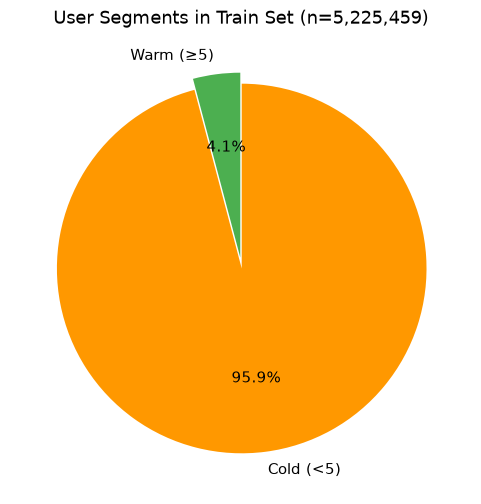

In [20]:
analyze_user_segment("num_train", "Train")

## Explore valid data

warm  users:   46,421  (6.0%)  |  warm  reviews: 141,212  (12.9%)
cold  users:  240,801  (31.1%)  |  cold  reviews: 341,601  (31.2%)
new   users:  486,632  (62.9%)  |  new   reviews: 611,919  (55.9%)


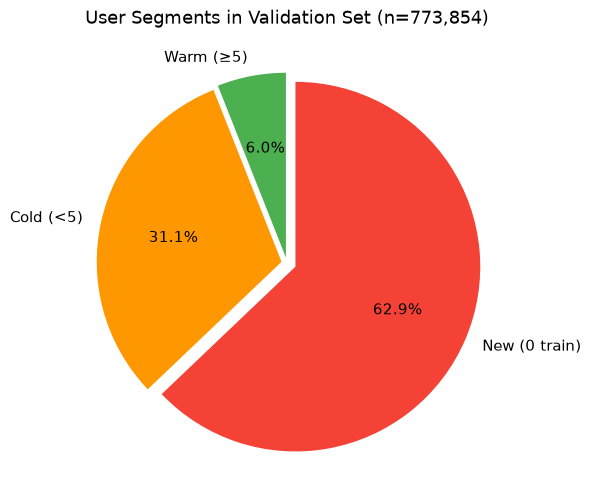

In [21]:
valid_stats = analyze_user_segment("num_valid", "Validation")

## Explore test data

warm  users:   38,636  (5.4%)  |  warm  reviews: 111,480  (10.2%)
cold  users:  203,215  (28.5%)  |  cold  reviews: 324,543  (29.6%)
new   users:  470,121  (66.0%)  |  new   reviews: 658,708  (60.2%)


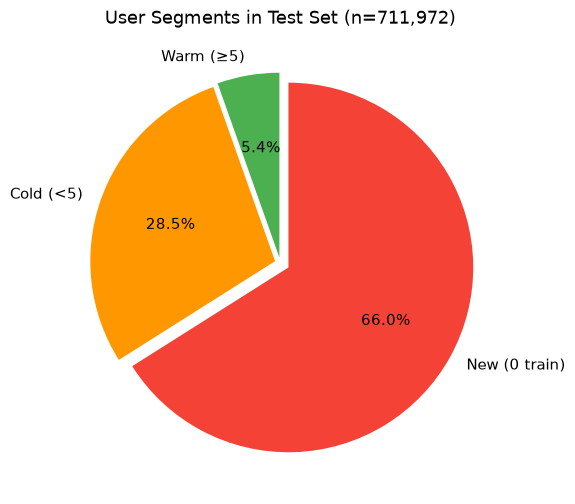

In [22]:
test_stats = analyze_user_segment("num_test", "Test")